# Runs Test Example

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/eabarnes1010/course_objective_analysis/blob/main/code/runsTest.ipynb)

*Elizabeth A. Barnes — BU Earth & Environment — Last updated: 2026-05-22*

## Learning objectives

- Define a *run* in a binary (sign) sequence and count runs in a time series.
- Build the theoretical distribution of runs expected under a random null and confirm it via Monte Carlo.
- Use the runs test to detect non-randomness (e.g., autocorrelation in red noise).


The runs test is a simple non-parametric way to ask whether a sequence is random. We count the number of *runs* (stretches of consecutive same-sign values) and compare that count to what would be expected if the signs were shuffled at random.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
from matplotlib import gridspec

# Figure defaults for this notebook.
plt.rcParams["figure.dpi"] = 150
plt.rcParams["figure.figsize"] = (6.0, 4.0)

rng = np.random.default_rng(12)

Define a helper to count the number of runs in a sequence by scanning the signs.

In [2]:
def count_runs(x):
    """Count runs of consecutive same-sign values in `x`.

    A run is a maximal stretch of consecutive values with the same sign.
    Returns the total number of runs (positive + negative).
    """
    Npos = 0
    Nneg = 0

    sgn = np.nan
    for val in x:
        if np.sign(val) != sgn:
            if np.sign(val) > 0:
                Npos += 1
            else:
                Nneg += 1
            sgn = np.sign(val)

    return Npos + Nneg

## Make some synthetic data to orient our brains

Before getting into formulas, let's draw `N = 100` values from a uniform distribution on [-1, 1] and color positive values red, negative values blue. We'll print the number of runs in the title.

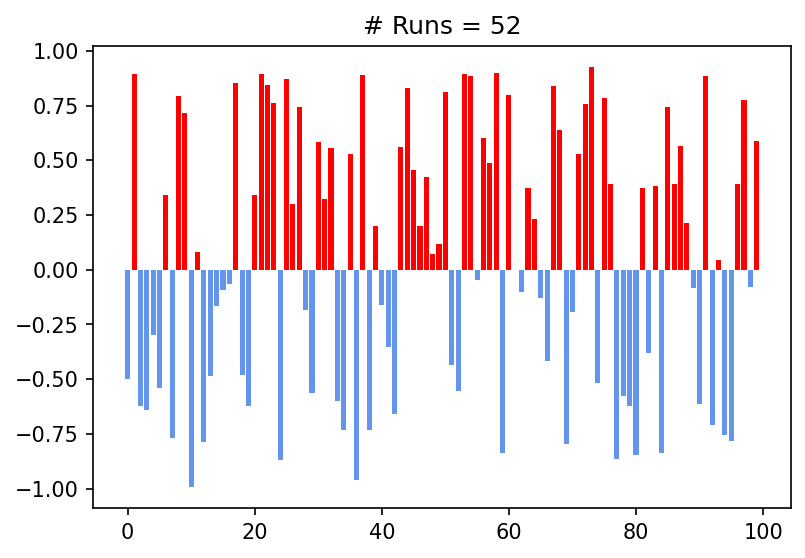

In [3]:
N = 100
x = rng.uniform(-1.0, 1.0, N)
for i, val in enumerate(x):
    if val > 0:
        plt.bar(i, val, color="red")
    else:
        plt.bar(i, val, color="cornflowerblue")

runs = count_runs(x)
plt.title(f"# Runs = {runs}")
plt.show()

For a random sequence with `Npos` positive and `Nneg` negative values, the number of runs is approximately normal with

$$\mu = 1 + \frac{2 N_{pos} N_{neg}}{N}, \quad \sigma = \sqrt{\frac{(\mu - 1)(\mu - 2)}{N - 1}}.$$

Compute these from our sample's positive/negative counts.

In [4]:
Npos = len(np.where(x > 0)[0])
Nneg = len(np.where(x < 0)[0])
print(f"# Positive = {Npos}, # Negative = {Nneg}")

# Theoretical mean and standard deviation of the runs distribution.
N = Npos + Nneg
muTheory = 1 + (2 * Npos * Nneg) / N
sigmaTheory = np.sqrt((muTheory - 1) * (muTheory - 2) / (N - 1))
print(f"muTheory = {muTheory}, sigmaTheory = {sigmaTheory}")

# Positive = 54, # Negative = 46
muTheory = 50.68, sigmaTheory = 4.942520520029137


Plot the theoretical normal distribution to see what range of run counts is plausible by chance.

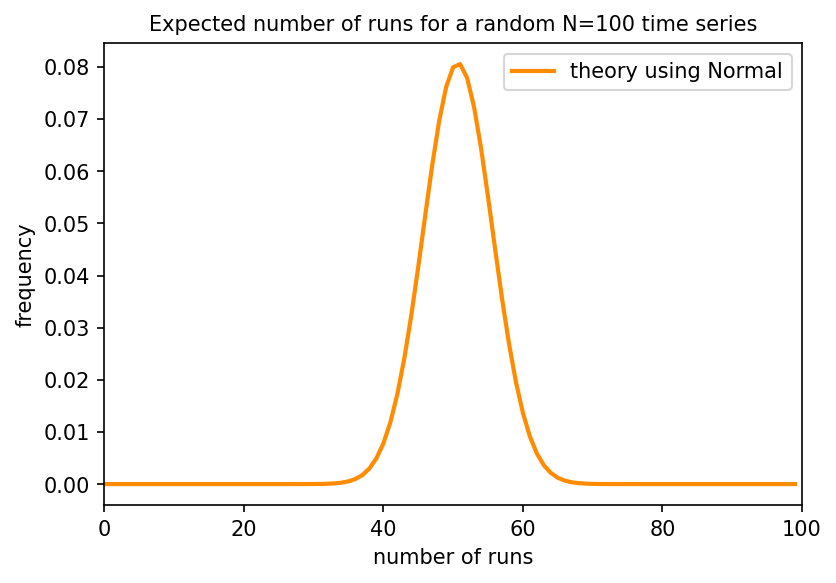

In [5]:
xbins = np.arange(0, N, 1)
plt.plot(
    xbins,
    stats.norm.pdf(xbins, loc=muTheory, scale=sigmaTheory),
    "-",
    color="darkorange",
    linewidth=2,
    label="theory using Normal",
)
plt.xlim(0, N)
plt.xlabel("number of runs")
plt.ylabel("frequency")
plt.title(f"Expected number of runs for a random N={N} time series", fontsize=10)
plt.legend()
plt.show()

Roughly 35–55 runs is the typical range expected by chance for a random `N = 100` series.

## Using Monte Carlo to check our intuition

Let's confirm that theoretical distribution by Monte Carlo. We draw 2000 random uniform series of length 100, count runs in each, and compare the empirical distribution to the theoretical curve.

In [6]:
N = 100
runs = np.zeros((2000,))
for iloop in np.arange(0, len(runs)):
    y = rng.uniform(-1.0, 1.0, N)
    runs[iloop] = count_runs(y)

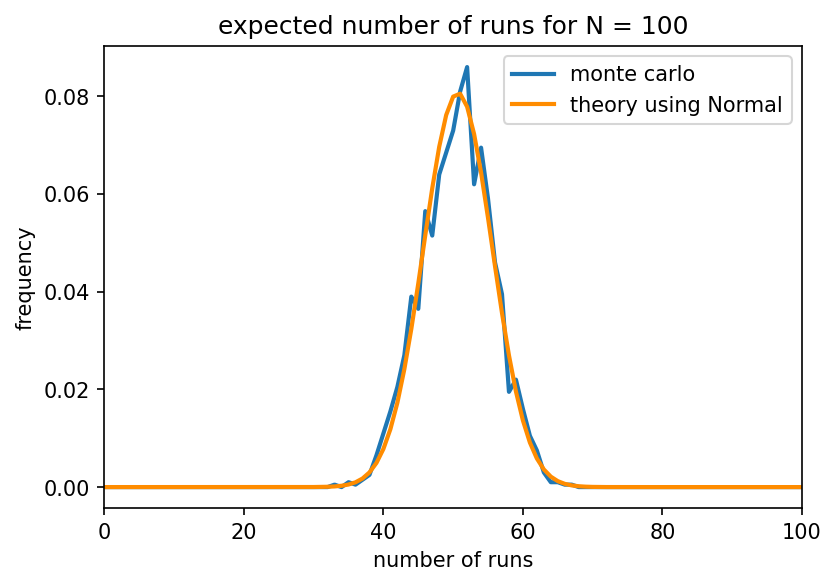

In [7]:
xbins = np.arange(0, 600, 1)
hx = np.histogram(runs, xbins)
plt.plot(xbins[:-1], hx[0] / len(runs), linewidth=2, label="monte carlo")
plt.plot(
    xbins[:-1],
    stats.norm.pdf(xbins[:-1], loc=muTheory, scale=sigmaTheory),
    "-",
    color="darkorange",
    linewidth=2,
    label="theory using Normal",
)
plt.xlim(0, N)
plt.xlabel("number of runs")
plt.ylabel("frequency")
plt.title(f"expected number of runs for N = {N}")
plt.legend()
plt.show()

The Monte Carlo histogram lines up beautifully with the theoretical normal curve. So we trust the theoretical reference.

## Examples for lecture

Two illustrative time series. The first is white noise (Gaussian iid) with values drawn from $\mathcal{N}(0, 1)$. The second is *red noise* — an AR(1) process — which has temporal persistence and therefore tends to produce **fewer runs** than a random sequence would.

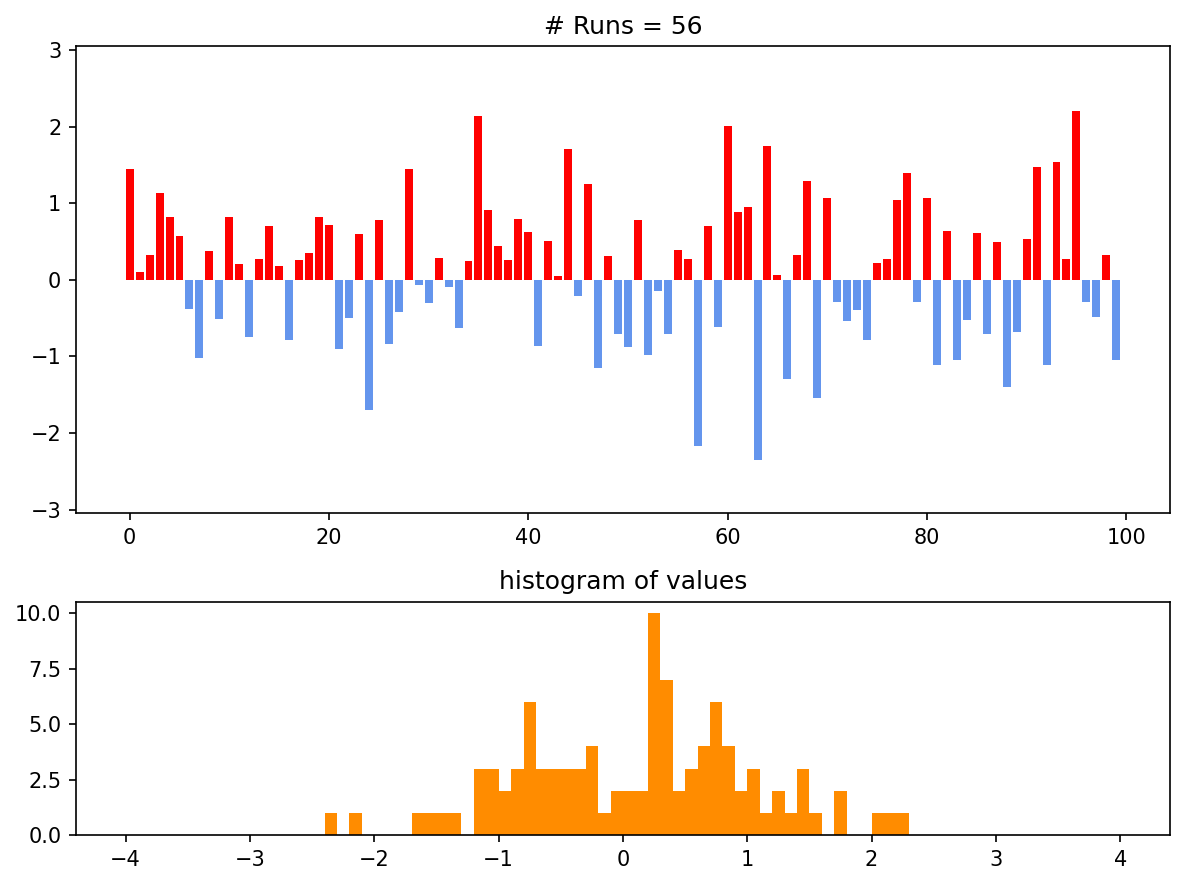

In [8]:
rng = np.random.default_rng(44)

N = 100
offset = 0
x = rng.normal(size=N)
series = []
for i, v in enumerate(x):
    if v < 0:
        val = v + offset
    else:
        val = v
    series.append(val)
series = np.asarray(series)

spec = gridspec.GridSpec(ncols=1, nrows=2, height_ratios=[2, 1])
fig = plt.figure(figsize=(8, 6))

ax0 = fig.add_subplot(spec[0])
i = np.where(series >= 0)
plt.bar(np.arange(0, N)[i], series[i], color="red")
i = np.where(series < 0)
plt.bar(np.arange(0, N)[i], series[i], color="cornflowerblue")
plt.ylim(-3.05, 3.05)
plt.title(f"# Runs = {count_runs(series)}")

ax1 = fig.add_subplot(spec[1])
plt.hist(series, bins=np.arange(-4, 4.1, 0.1), color="darkorange")
plt.title("histogram of values")

plt.tight_layout()
plt.show()

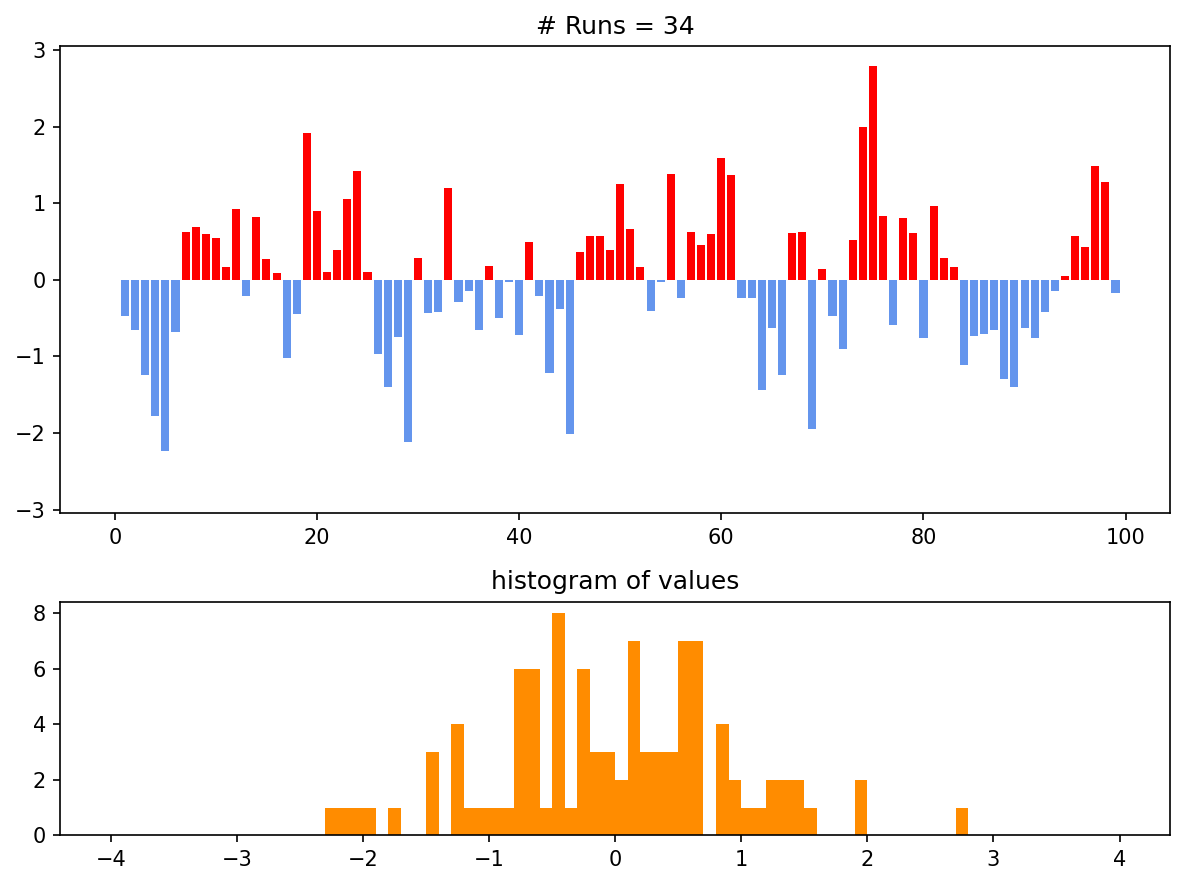

In [9]:
rng = np.random.default_rng(66)


def generate_red_noise(n, r):
    """Generate an AR(1) red-noise series of length `n` with lag-1 autocorrelation `r`."""
    white_noise = rng.normal(size=n)
    red_noise = np.zeros_like(white_noise)
    for i in range(1, n):
        red_noise[i] = r * red_noise[i - 1] + np.sqrt(1 - r**2) * white_noise[i]
    return red_noise


n = 100  # Length of the time series.
r = 0.5  # Autocorrelation coefficient.

red_noise = generate_red_noise(n, r)

spec = gridspec.GridSpec(ncols=1, nrows=2, height_ratios=[2, 1])
fig = plt.figure(figsize=(8, 6))

ax0 = fig.add_subplot(spec[0])
i = np.where(red_noise >= 0)
plt.bar(np.arange(0, N)[i], red_noise[i], color="red")
i = np.where(red_noise < 0)
plt.bar(np.arange(0, N)[i], red_noise[i], color="cornflowerblue")
plt.ylim(-3.05, 3.05)
plt.title(f"# Runs = {count_runs(red_noise)}")

ax1 = fig.add_subplot(spec[1])
plt.hist(red_noise, bins=np.arange(-4, 4.1, 0.1), color="darkorange")
plt.title("histogram of values")

plt.tight_layout()
plt.show()

## Wrap-up

- A *run* is a maximal stretch of consecutive same-sign values. For a random sequence the number of runs is approximately normal with mean and variance set by the positive/negative counts.
- Monte Carlo confirms the theoretical distribution closely.
- Red-noise time series tend to have **fewer runs** than the random-null distribution predicts, which is exactly the kind of departure the runs test is designed to detect.